
 РЕЗУЛЬТАТИ АНАЛІЗУ: Bing Maps
Авто-вирівнювання: зсув на X=0.18px, Y=0.03px
Total GT: 114
Total Preds: 90
TP (Знайдено): 62
FP (Хибні): 33
FN (Пропуски): 52
Фрагментовані (Over-segmented): 16
Precision: 65.26%
Recall: 54.39%
F1-Score: 59.33%


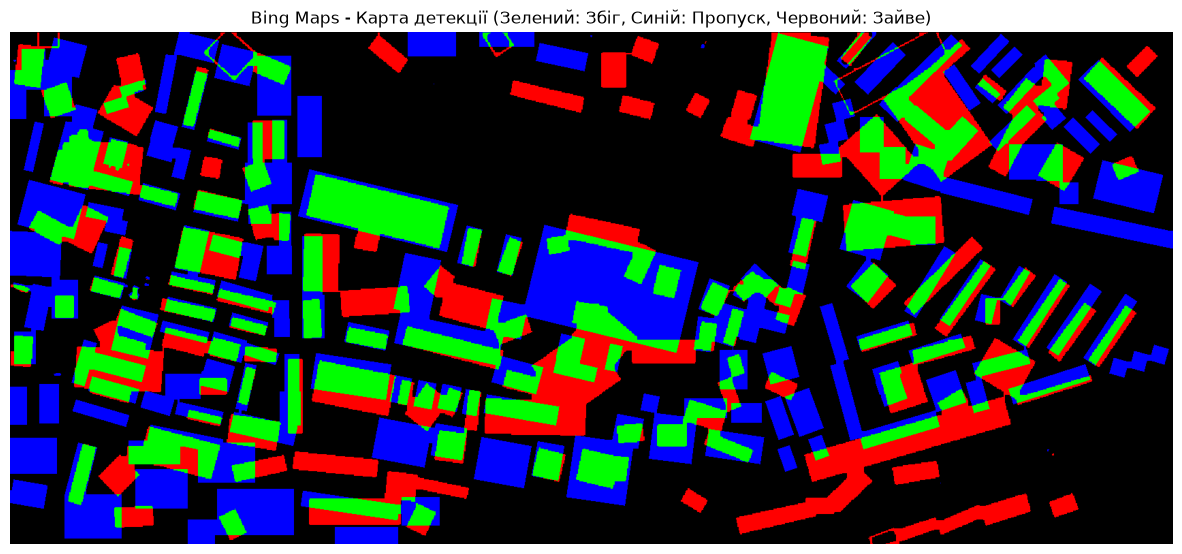


 РЕЗУЛЬТАТИ АНАЛІЗУ: Google Maps
Авто-вирівнювання: зсув на X=-16.88px, Y=14.99px
Total GT: 114
Total Preds: 224
TP (Знайдено): 70
FP (Хибні): 141
FN (Пропуски): 44
Фрагментовані (Over-segmented): 25
Precision: 33.18%
Recall: 61.4%
F1-Score: 43.08%


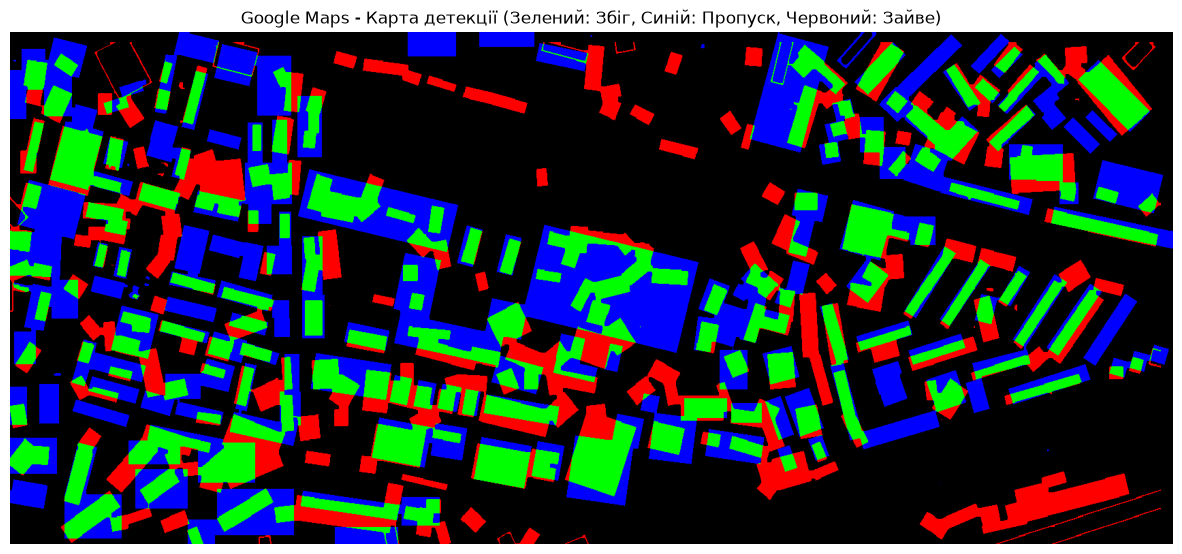


 РЕЗУЛЬТАТИ АНАЛІЗУ: Bing Maps vs Google Maps
Авто-вирівнювання: зсув на X=-11.95px, Y=10.36px
Total GT: 91
Total Preds: 202
TP (Знайдено): 55
FP (Хибні): 123
FN (Пропуски): 36
Фрагментовані (Over-segmented): 16
Precision: 30.9%
Recall: 60.44%
F1-Score: 40.89%


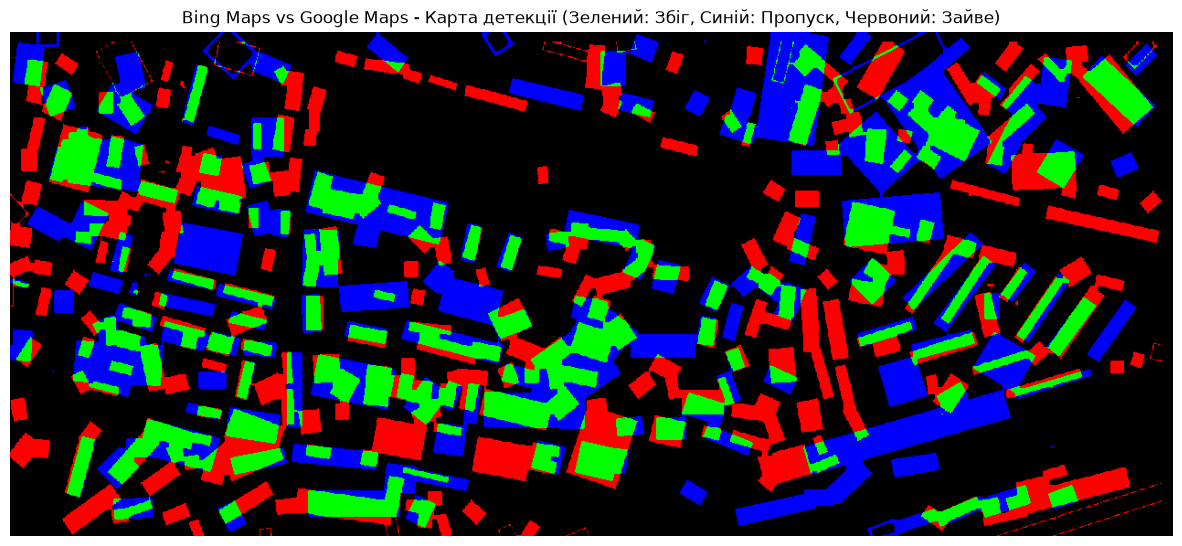

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def extract_filled_boxes(image_path):
    """
    Завантажує зображення, знаходить червоні рамки та перетворює їх в сплошну бінарну маску.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Не знайдено файл: {image_path}")
        
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
    # Червоний колір в HSV знаходится на двух краях спектру (0-10 та 170-180)
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])
        
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    red_mask = mask1 | mask2
        
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    red_mask = cv2.morphologyEx(red_mask, cv2.MORPH_CLOSE, kernel, iterations=2)
        
    # Знаходимо контури рамок і заливаємо їх всередині
    contours, _ = cv2.findContours(red_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(red_mask)
    cv2.drawContours(filled_mask, contours, -1, 255, -1)
        
    return img, filled_mask

def evaluate_detection(gt_mask, pred_mask, overlap_threshold=0.4):
    """
    Порівнює маску еталону та маску детекції з урахуванням проблеми Over-segmentation.
    """
    # Знаходимо окремі будівлі на еталоні (Ground Truth)
    num_gt, gt_labels, gt_stats, _ = cv2.connectedComponentsWithStats(gt_mask, connectivity=8)
    # Знаходимо окремі будівлі на програмній детекції (Predictions)
    num_pred, pred_labels, pred_stats, _ = cv2.connectedComponentsWithStats(pred_mask, connectivity=8)
        
    tp = 0
    over_segmented = 0
    matched_preds = set()
        
    # Перевіряємо кожну будівлю з еталону (індекс 0 - це фон, тому пропускаємо)
    for i in range(1, num_gt):
        gt_area = gt_stats[i, cv2.CC_STAT_AREA]
            
        # Виділямєо тільки текущее эталонное здание
        single_gt_mask = (gt_labels == i).astype(np.uint8)
            
        # Знаходимо перетин будівлі з програмною маскою
        intersection = cv2.bitwise_and(single_gt_mask, pred_mask)
        intersect_area = np.count_nonzero(intersection)
            
        # Якщо прогрмні рамки покривають хоча б 40% еталоної будівлі
        if (intersect_area / gt_area) >= overlap_threshold:
            tp += 1
                
            intersecting_preds = np.unique(pred_labels[intersection > 0])
            intersecting_preds = intersecting_preds[intersecting_preds > 0] # Прибираємо фон
                
            matched_preds.update(intersecting_preds)
                
            # Якщо будівля зацепила 2 и більше рамок — це over-segmentation
            if len(intersecting_preds) > 1:
                over_segmented += 1
                    
    # FN (False Negatives) - будівлі на еталоні, які не були знайдені програмно
    fn = (num_gt - 1) - tp
        
    # FP (False Positives) - програмні рамки, які ні з чим не перетинаются
    fp = (num_pred - 1) - len(matched_preds)
        
    # Обрахунок значень
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
    return {
        "Total GT": num_gt - 1,
        "Total Preds": num_pred - 1,
        "TP (Знайдено)": tp,
        "FP (Хибні)": fp,
        "FN (Пропуски)": fn,
        "Фрагментовані (Over-segmented)": over_segmented,
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1-Score": round(f1_score * 100, 2)
    }

def analyze_and_visualize(etalon_path, pred_path, title):
    # Витягуємо маски та зображення
    gt_img, gt_mask = extract_filled_boxes(etalon_path)
    pred_img, pred_mask = extract_filled_boxes(pred_path)
        
    # Блок виправлення розмірів
    height, width = gt_mask.shape
    if pred_mask.shape != gt_mask.shape:
        pred_img = cv2.resize(pred_img, (width, height), interpolation=cv2.INTER_LINEAR)
        pred_mask = cv2.resize(pred_mask, (width, height), interpolation=cv2.INTER_NEAREST)
            
    # Блок авто-вирівнювання:
    # Переводимо в градації сірого для пошуку зсуву
    gt_gray = cv2.cvtColor(gt_img, cv2.COLOR_BGR2GRAY)
    pred_gray = cv2.cvtColor(pred_img, cv2.COLOR_BGR2GRAY)
        
    # Фазова кореляція знаходить точний зсув (x, y) між двома картинками у пікселях
    shift, _ = cv2.phaseCorrelate(np.float64(pred_gray), np.float64(gt_gray))
    dx, dy = shift
        
    # Створюємо матрицю трансформації та зсуваємо маску детекції на знайдені пікселі
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    aligned_pred_mask = cv2.warpAffine(pred_mask, M, (width, height))
        
    # Оцінюємо вже ідеально вирівняні маски
    results = evaluate_detection(gt_mask, aligned_pred_mask)
        
    # Вивід результатів
    print(f"\n{'='*40}")
    print(f" РЕЗУЛЬТАТИ АНАЛІЗУ: {title}")
    print(f"{'='*40}")
    print(f"Авто-вирівнювання: зсув на X={round(dx, 2)}px, Y={round(dy, 2)}px")
    for key, value in results.items():
        if "Precision" in key or "Recall" in key or "F1" in key:
            print(f"{key}: {value}%")
        else:
            print(f"{key}: {value}")
                
    # Візуалізація різниці
    diff_img = np.zeros_like(gt_img)
    diff_img[gt_mask == 255] = [255, 0, 0]    # Синій - Пропуски
    diff_img[aligned_pred_mask == 255] = [0, 0, 255]  # Червоний - Хибні (мусор)
    diff_img[(gt_mask == 255) & (aligned_pred_mask == 255)] = [0, 255, 0] # Зелений - Збіг
        
    diff_img_rgb = cv2.cvtColor(diff_img, cv2.COLOR_BGR2RGB)
        
    plt.figure(figsize=(15, 7))
    plt.imshow(diff_img_rgb)
    plt.title(f"{title} - Карта детекції (Зелений: Збіг, Синій: Пропуск, Червоний: Зайве)")
    plt.axis('off')
    plt.show()

# Запуск аналізу
etalon_file = r"./sources/etalon_detection.png"

# Аналіз Bing Maps
bing_result_file = r"./sources/bing_detect.png" 
analyze_and_visualize(etalon_file, bing_result_file, "Bing Maps")

# Аналіз Google Maps
google_result_file = r"./sources/google_detect.png"
analyze_and_visualize(etalon_file, google_result_file, "Google Maps")

# Аналіз схожості результатів Bing Maps та Google Maps
analyze_and_visualize(bing_result_file, google_result_file, "Bing Maps vs Google Maps")